# Spotify Song Popularity Prediction

This GitHub-ready notebook uses Spotify audio features to predict whether a song is popular or not popular. It follows a complete beginner-friendly machine learning workflow from data loading to model evaluation and prediction.


## 1. Problem Statement

The goal of this project is to build a machine learning model that predicts whether a song is popular based on its audio features.

In this project, songs with a popularity score of **70 or higher** are considered **popular**. Songs below 70 are considered **not popular**.

## 2. Data Loading

First, we install and import the required libraries. Then we load the Spotify dataset and look at the first few rows to understand what the data looks like.

In [32]:
# Install required libraries
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Load the dataset
df = pd.read_csv('dataset.csv')

# Show the first five rows
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [35]:
# Check the number of rows and columns
df.shape

(114000, 21)

In [36]:
# Check column names, data types, and basic statistics
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 3. Data Cleaning

Before building the model, we clean the dataset by checking missing values and removing columns that are not useful for prediction.

In [37]:
# Check missing values before cleaning
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [38]:
# Remove rows with missing values
df = df.dropna()

# Remove the extra index column if it exists
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Check missing values after cleaning
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [39]:
# Check the cleaned dataset size
df.shape

(113999, 20)

## 4. Exploratory Data Analysis (EDA)

In this section, we explore the popularity score and audio features to understand the dataset before training a model.

In [40]:
# Study the popularity score column
df['popularity'].describe()

count    113999.000000
mean         33.238827
std          22.304959
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

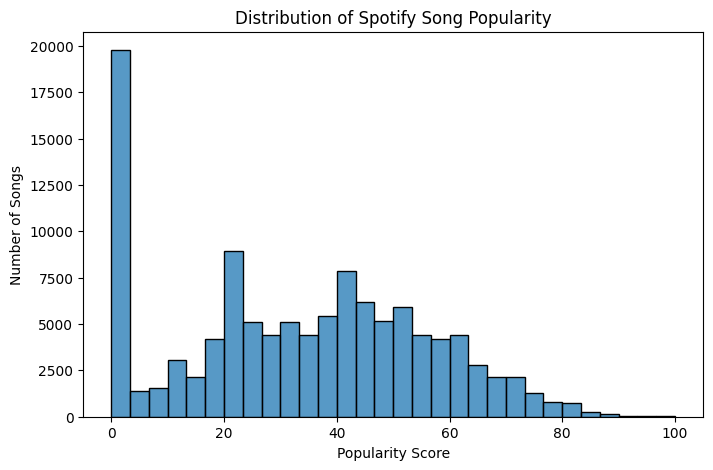

In [41]:
# Visualize the distribution of popularity scores
plt.figure(figsize=(8, 5))
sns.histplot(df['popularity'], bins=30)
plt.title('Distribution of Spotify Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Songs')
plt.show()

## 5. Feature Engineering

We create a binary target variable where songs with popularity **70 or higher** are marked as `1` for popular, and all other songs are marked as `0` for not popular.

In [42]:
# Create a popular/not popular target column
df['is_popular'] = df['popularity'].apply(lambda score: 1 if score >= 70 else 0)

# Preview the new column
df[['track_name', 'popularity', 'is_popular']].head()

,track_name,popularity,is_popular
0,Comedy,73,1
1,Ghost - Acoustic,55,0
2,To Begin Again,57,0
3,Can't Help Falling In Love,71,1
4,Hold On,82,1


Not Popular Songs: 108527
Popular Songs: 5472


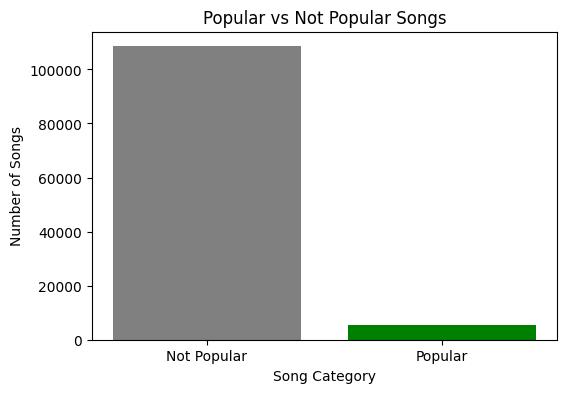

In [43]:
# Count popular and not popular songs
popular_count = df['is_popular'].value_counts()

not_popular = popular_count[0]
popular = popular_count[1]

print('Not Popular Songs:', not_popular)
print('Popular Songs:', popular)

# Visualize the class count
plt.figure(figsize=(6, 4))
plt.bar(['Not Popular', 'Popular'], [not_popular, popular], color=['gray', 'green'])
plt.title('Popular vs Not Popular Songs')
plt.xlabel('Song Category')
plt.ylabel('Number of Songs')
plt.show()

In [44]:
# Select audio features for analysis
audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

# Compare average audio features for popular and not popular songs
df.groupby('is_popular')[audio_features].mean()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
is_popular,,,,,,,,,
0,0.564317,0.639887,-8.339402,0.085123,0.319632,0.162077,0.215650,0.472532,122.249246
1,0.616051,0.671062,-6.663338,0.075320,0.221188,0.036544,0.171987,0.504489,120.133624


In [45]:
# Check correlation between numeric columns and popularity
number_columns = df.select_dtypes(include=['int64', 'float64', 'bool'])
number_columns.corr()['popularity'].sort_values(ascending=False)

popularity          1.000000
is_popular          0.429407
loudness            0.050420
explicit            0.044078
danceability        0.035444
time_signature      0.031076
tempo               0.013212
energy              0.001053
key                -0.003847
liveness           -0.005397
duration_ms        -0.007129
mode               -0.013948
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64

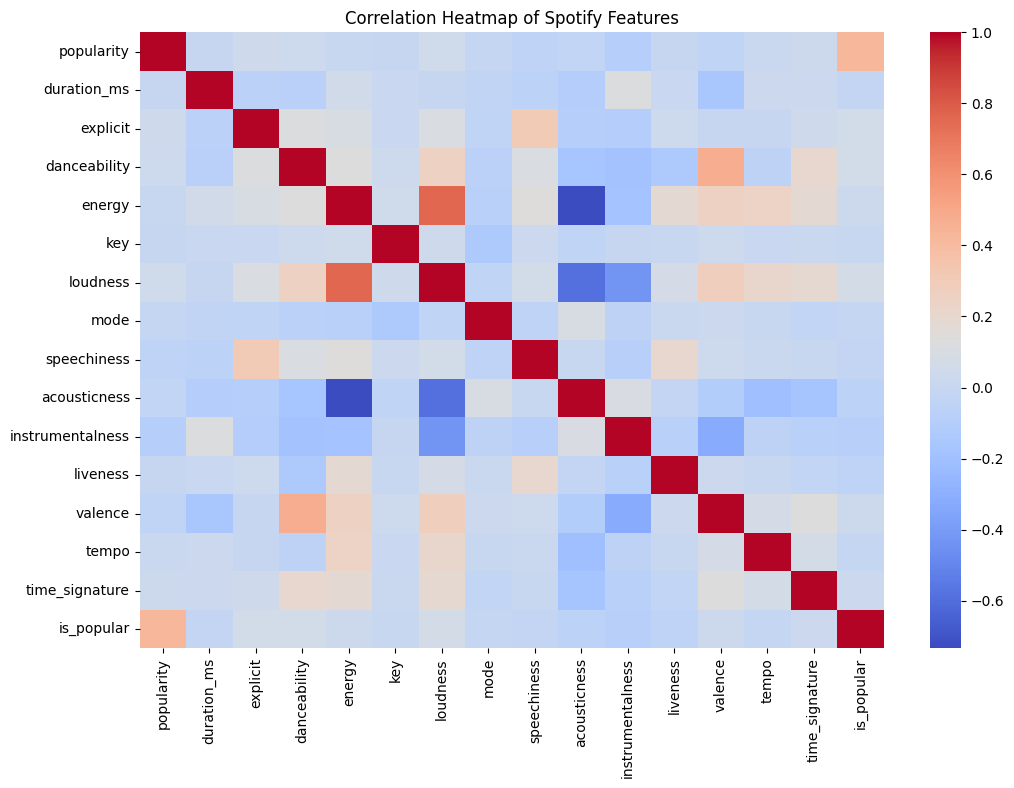

In [46]:
# Visualize correlations between numeric features
plt.figure(figsize=(12, 8))
sns.heatmap(number_columns.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap of Spotify Features')
plt.show()

In [47]:
# Choose input features and target column
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'explicit'
]

X = df[features]
y = df['is_popular']

## 6. Model Building

Now we split the data into training and testing sets. The models learn from the training data and are tested on data they have not seen before.

The regular Logistic Regression model is kept as a **baseline model**. A baseline gives us a simple starting point to compare stronger models against.

In [48]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 91199
Testing rows: 22800


In [49]:
# Baseline model: regular Logistic Regression
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
# Balanced Logistic Regression model
balanced_model = LogisticRegression(max_iter=1000, class_weight='balanced')
balanced_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [51]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 7. Model Evaluation

We compare three models: Baseline Logistic Regression, Balanced Logistic Regression, and Random Forest.

Accuracy can be misleading in this project because only about **5% of songs are popular**. A model can get high accuracy by predicting almost everything as not popular, but that does not mean it is good at finding popular songs.

In [52]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [53]:
# Make predictions with each model
baseline_predictions = baseline_model.predict(X_test)
balanced_predictions = balanced_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

In [54]:
# Compare model performance
model_results = []

models = [
    ['Baseline Logistic Regression', baseline_predictions],
    ['Balanced Logistic Regression', balanced_predictions],
    ['Random Forest', rf_predictions]
]

for model_name, predictions in models:
    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    model_results.append({
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_test, predictions), 3),
        'Popular Precision': round(report['1']['precision'], 3),
        'Popular Recall': round(report['1']['recall'], 3),
        'Popular F1-Score': round(report['1']['f1-score'], 3)
    })

model_results_df = pd.DataFrame(model_results)
model_results_df

,Model,Accuracy,Popular Precision,Popular Recall,Popular F1-Score
0,Baseline Logistic Regression,0.952,0.000,0.000,0.000
1,Balanced Logistic Regression,0.578,0.078,0.717,0.140
2,Random Forest,0.972,0.741,0.625,0.678


In [55]:
# Detailed classification reports
for model_name, predictions in models:
    print(model_name)
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, predictions))
    print('Classification Report:')
    print(classification_report(y_test, predictions, zero_division=0))
    print('-' * 50)

Baseline Logistic Regression
Confusion Matrix:
[[21706     0]
 [ 1094     0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     21706
           1       0.00      0.00      0.00      1094

    accuracy                           0.95     22800
   macro avg       0.48      0.50      0.49     22800
weighted avg       0.91      0.95      0.93     22800

--------------------------------------------------
Balanced Logistic Regression
Confusion Matrix:
[[12400  9306]
 [  310   784]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.57      0.72     21706
           1       0.08      0.72      0.14      1094

    accuracy                           0.58     22800
   macro avg       0.53      0.64      0.43     22800
weighted avg       0.93      0.58      0.69     22800

--------------------------------------------------
Random Forest
Confusion Matrix:
[[21467   

## 8. Handling Class Imbalance

The target column is imbalanced because most songs are not popular. This is why the baseline Logistic Regression model may predict only class 0.

To handle this, the Balanced Logistic Regression model uses `class_weight='balanced'`, which gives more importance to the smaller popular-song class during training.

In [56]:
# Check which features were most important for Random Forest
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
4,acousticness,0.121572
1,energy,0.117852
2,loudness,0.115234
5,instrumentalness,0.113536
6,liveness,0.107735
7,valence,0.105947
8,tempo,0.104032
0,danceability,0.102065
3,speechiness,0.101421
9,explicit,0.010605


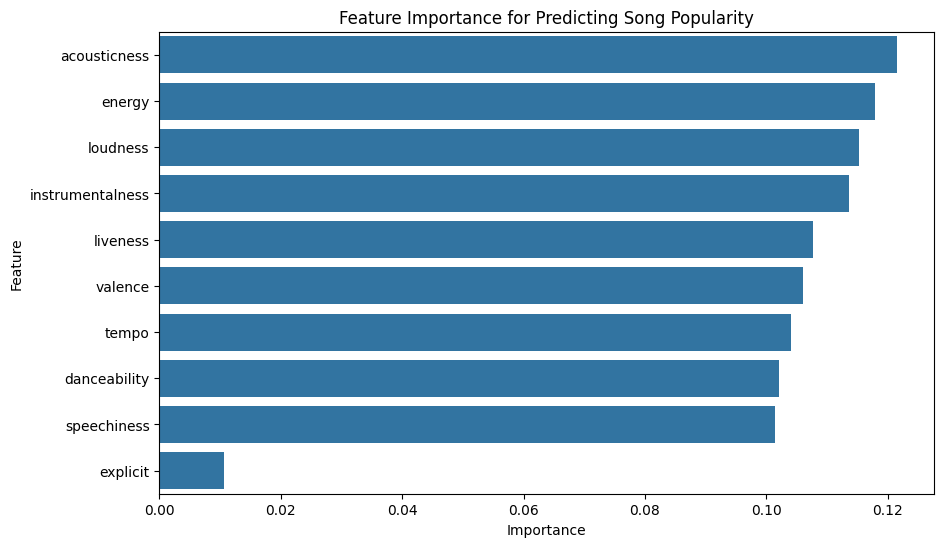

In [57]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Predicting Song Popularity')
plt.show()

## 9. Probability-Based Predictions

A model can give both a final prediction and a probability score. The final prediction says popular or not popular, while the probability shows how confident the model is.

In [58]:
# Create example songs to test the model
new_song = pd.DataFrame([{
    'danceability': 0.70,
    'energy': 0.75,
    'loudness': -5,
    'speechiness': 0.05,
    'acousticness': 0.20,
    'instrumentalness': 0.00,
    'liveness': 0.10,
    'valence': 0.50,
    'tempo': 120,
    'explicit': 0
}])

new_song_2 = pd.DataFrame([{
    'danceability': 0.78,
    'energy': 0.82,
    'loudness': -4.5,
    'speechiness': 0.06,
    'acousticness': 0.15,
    'instrumentalness': 0.00,
    'liveness': 0.12,
    'valence': 0.58,
    'tempo': 124,
    'explicit': 1
}])

new_song_3 = pd.DataFrame([{
    'danceability': 0.35,
    'energy': 0.25,
    'loudness': -15,
    'speechiness': 0.04,
    'acousticness': 0.85,
    'instrumentalness': 0.60,
    'liveness': 0.30,
    'valence': 0.20,
    'tempo': 70,
    'explicit': 0
}])

new_song_max = pd.DataFrame([{
    'danceability': 0.80,
    'energy': 0.85,
    'loudness': -4.0,
    'speechiness': 0.06,
    'acousticness': 0.12,
    'instrumentalness': 0.00,
    'liveness': 0.10,
    'valence': 0.60,
    'tempo': 125,
    'explicit': 1
}])

In [59]:
# Compare predictions for all example songs
song_names = ['new_song', 'new_song_2', 'new_song_3', 'new_song_max']
song_data = [new_song, new_song_2, new_song_3, new_song_max]

results = []

for i in range(len(song_names)):
    prediction = rf_model.predict(song_data[i])[0]
    probability = rf_model.predict_proba(song_data[i])[0][1]

    if prediction == 1:
        prediction_text = 'Popular'
    else:
        prediction_text = 'Not Popular'

    results.append([song_names[i], prediction_text, round(probability, 3)])

prediction_results_df = pd.DataFrame(results, columns=['Song', 'Prediction', 'Probability'])
prediction_results_df

,Song,Prediction,Probability
0,new_song,Not Popular,0.250
1,new_song_2,Not Popular,0.105
2,new_song_3,Not Popular,0.000
3,new_song_max,Not Popular,0.141


**Important note:** `predict()` gives the final answer. `predict_proba()` gives the probability. A song can have some chance of being popular, such as 0.30, but still be predicted as not popular because 0.30 is below the normal 0.50 cutoff.

## 10. Hit Song Simulation

In this section, we randomly generate many possible songs and use the trained Random Forest model to find which ones have the highest predicted popularity probability.

In [60]:
# Generate random candidate songs
np.random.seed(42)
number_of_songs = 10000

candidate_songs = pd.DataFrame()
candidate_songs['danceability'] = np.random.uniform(0.3, 0.95, number_of_songs)
candidate_songs['energy'] = np.random.uniform(0.3, 0.95, number_of_songs)
candidate_songs['loudness'] = np.random.uniform(-12, -2, number_of_songs)
candidate_songs['speechiness'] = np.random.uniform(0.02, 0.25, number_of_songs)
candidate_songs['acousticness'] = np.random.uniform(0.0, 0.6, number_of_songs)
candidate_songs['instrumentalness'] = np.random.uniform(0.0, 0.2, number_of_songs)
candidate_songs['liveness'] = np.random.uniform(0.05, 0.4, number_of_songs)
candidate_songs['valence'] = np.random.uniform(0.2, 0.9, number_of_songs)
candidate_songs['tempo'] = np.random.uniform(70, 180, number_of_songs)
candidate_songs['explicit'] = np.random.choice([0, 1], number_of_songs)

candidate_songs['popular_probability'] = rf_model.predict_proba(candidate_songs)[:, 1]

top_songs = candidate_songs.sort_values('popular_probability', ascending=False).head(10)
top_songs

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,explicit,popular_probability
2804,0.638949,0.831105,-2.853102,0.037964,0.271895,0.112777,0.150667,0.329242,117.968038,1,0.318686
7634,0.733778,0.596209,-6.729114,0.056956,0.250112,0.000303,0.178021,0.639900,103.443455,1,0.259520
5644,0.687625,0.461863,-6.991687,0.173122,0.071899,0.062030,0.134125,0.215668,83.943737,1,0.255430
8776,0.932900,0.434418,-5.848242,0.202695,0.591135,0.188834,0.112956,0.616401,129.751963,1,0.248206
8942,0.861325,0.566893,-4.904952,0.047818,0.073304,0.013660,0.101197,0.797087,87.507871,0,0.215918
3550,0.822473,0.525568,-3.526500,0.040189,0.149000,0.010576,0.124988,0.388492,87.031548,1,0.212978
121,0.882459,0.462094,-2.467840,0.095824,0.050430,0.011240,0.163799,0.456066,144.465768,0,0.212373
2143,0.504328,0.413864,-3.698566,0.192210,0.548743,0.018606,0.071749,0.441429,91.850314,1,0.208686
1117,0.870350,0.643723,-3.976560,0.205203,0.344564,0.020128,0.161701,0.355157,91.170243,1,0.207841
9347,0.861537,0.679158,-5.386574,0.105284,0.545293,0.004875,0.097921,0.243429,102.430156,0,0.203720


In [61]:
# Show the best generated candidate song
top_song = top_songs.iloc[0]
top_song

danceability             0.638949
energy                   0.831105
loudness                -2.853102
speechiness              0.037964
acousticness             0.271895
instrumentalness         0.112777
liveness                 0.150667
valence                  0.329242
tempo                  117.968038
explicit                 1.000000
popular_probability      0.318686
Name: 2804, dtype: float64

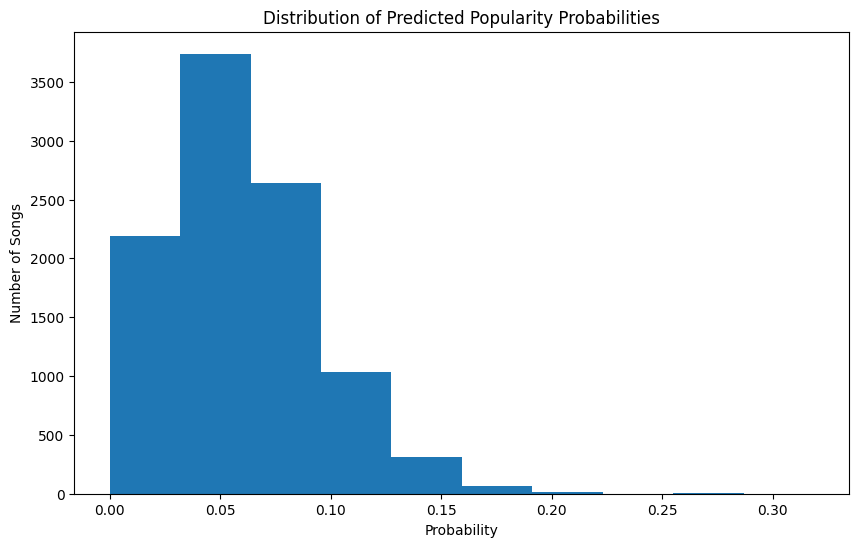

In [62]:
# Plot predicted popularity probabilities for generated songs
plt.figure(figsize=(10, 6))
plt.hist(candidate_songs['popular_probability'], bins=10)
plt.title('Distribution of Predicted Popularity Probabilities')
plt.xlabel('Probability')
plt.ylabel('Number of Songs')
plt.show()

In [63]:
# Group generated songs by probability range
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]

candidate_songs['probability_group'] = pd.cut(candidate_songs['popular_probability'], bins=bins)

bucket_counts = candidate_songs['probability_group'].value_counts().sort_index()
bucket_percent = (bucket_counts / number_of_songs) * 100

result = pd.DataFrame()
result['Count'] = bucket_counts
result['Percentage'] = bucket_percent.round(2)

result

,Count,Percentage
probability_group,,
"(0.0, 0.1]",8879,88.79
"(0.1, 0.2]",976,9.76
"(0.2, 0.3]",9,0.09
"(0.3, 0.4]",1,0.01
"(0.4, 0.5]",0,0.00
"(0.5, 1.0]",0,0.00


## 11. Key Insights and Recommendations

### What I learned from this project

- I learned how to load a dataset using pandas.
- I learned how to check the size of the dataset using `df.shape`.
- I learned how to check missing values using `df.isnull().sum()`.
- I learned how to clean the dataset by removing missing values and unnecessary columns.
- I learned how to create a new target column called `is_popular`.
- I learned how to visualize data using bar charts, histograms, and heatmaps.
- I learned how to compare popular and not popular songs using audio features.
- I learned how to split data into training and testing sets.
- I learned how to train Logistic Regression and Random Forest models.
- I learned how to evaluate a model using accuracy, confusion matrix, and classification report.
- I learned that model prediction and probability are not exactly the same thing.
- I learned how to test new made-up songs using the trained model.
- I learned how to generate many random song combinations and find which ones the model thinks have the best chance of being popular.

### Important findings

- Most songs in the dataset are not popular, so the dataset is imbalanced.
- A song was considered popular if its popularity score was 70 or higher.
- The model learned patterns from audio features like danceability, energy, loudness, acousticness, instrumentalness, valence, tempo, and explicit content.
- Random Forest was useful because it made predictions and also showed feature importance.
- Probability scores were useful because they gave more detail than only saying popular or not popular.

### Prediction vs probability

`predict()` gives the final class: Popular or Not Popular.

`predict_proba()` gives the chance or probability of being popular.

For example, if a song has a probability of 0.30, that means the model gives it a 30% chance of being popular. But because 0.30 is below 0.50, the final prediction is still Not Popular.

### Recommendations

- Songs with stronger energy, danceability, and loudness may have a better chance of being predicted as popular.
- Songs with very high acousticness or instrumentalness may be less likely to be predicted as popular in this dataset.
- It is better to look at probability, not only the final Yes or No prediction.
- Balanced models are helpful because the dataset has many more not popular songs than popular songs.
- More data about popular songs could improve the model.
- Popularity does not depend only on audio features. Artist popularity, playlists, marketing, social media trends, and release timing also matter.
